**Не зафиксировал объективно, повлияля ли видеокарта на скорость обчения. Поэтому лучше перед выполнением ячеек всё же переключиться на графический процессор.**

# **Практическое занятие: RNN, LSTM и GRU**

В этом блокноте мы проведём эксперименты с рекуррентными сетями, чтобы на практике увидеть, как они справляются с долгосрочными зависимостями и как LSTM/GRU решают проблему затухающих градиентов. Мы используем PyTorch и Google Colab.

**План практики:**
1. **Adding problem** – синтетическая задача, требующая запоминания информации на большом расстоянии. Сравним vanilla RNN, LSTM и GRU, визуализируем градиенты.
2. **Классификация тональности на русском языке** – используем датасет RuSentiment, построим BiLSTM, сравним однонаправленную и двунаправленную модели, визуализируем скрытые состояния через t-SNE.

👉 *Инструкция:* Запускайте ячейки последовательно, меняйте гиперпараметры, где предложено, и отвечайте на вопросы для интерпретации.

## **1. Установка и импорт библиотек**

In [2]:
!pip install -q datasets transformers scikit-learn matplotlib seaborn

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/alexprog/torch_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## **2. Эксперимент 1: Adding problem (задача на долгосрочные зависимости)**

**Описание задачи:** Даётся последовательность случайных чисел $x_1, \dots, x_T$ (обычно T=100) и два индекса $i$ и $j$ (первый в первой половине, второй – во второй). Цель – рассчитать сумму $x_i + x_j$. Модель должна запомнить значения на больших расстояниях.

Мы сравним три модели: **vanilla RNN**, **LSTM**, **GRU**. Будем отслеживать:
- потери на валидации
- нормы градиентов для разных шагов времени (чтобы увидеть затухание)

Здесь формируются numpy вектора на выходе.

In [2]:
def generate_adding_problem_data(num_samples, seq_len=100):
    """
    Генерирует синтетический датасет для adding problem.
    Возвращает: X (num_samples, seq_len, 2) – два канала: значение и индикатор позиции,
                y (num_samples) – сумма двух выбранных чисел.
    """
    X = np.random.uniform(0, 1, (num_samples, seq_len, 2)).astype(np.float32)
    y = np.zeros((num_samples,), dtype=np.float32)
    for i in range(num_samples):
        # выбираем случайные индексы: первый в первой половине, второй – во второй
        idx1 = np.random.randint(0, seq_len // 2)
        idx2 = np.random.randint(seq_len // 2, seq_len)
        X[i, idx1, 1] = 1.0
        X[i, idx2, 1] = 1.0
        y[i] = X[i, idx1, 0] + X[i, idx2, 0]
    return X, y

# Генерируем train и val
seq_len = 100
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 100, 2), Val shape: (1000, 100, 2)


Здесь из numpy векторов преобразование в тензоры pytorch и j,]trns lkz elj,cndf gjkextybz byajhvfwbb/

In [11]:
class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)  # для MSE функция в PyTorch, которая добавляет новое измерение размером 1 к тензору в указанной позиции (индекс измерения)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
batch_size = 128
train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Построение классической рекуррентной нейросети

In [12]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Если batch_first = True, то входные и выходные тензоры имеют форму (batch_size, seq_len, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])  # используем последний скрытый
        return out



In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out



In [14]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

Реализация цикла обучения одной сети. Запоминает нормы градиентов

In [47]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, clip=1.0, use_scheduler=False):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3,min_lr=lr)
        
    train_losses, val_losses = [], []
    grad_norms = []  # для отслеживания норм градиентов (по эпохам)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            # Обрезка градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            # Сохраняем норму градиентов для анализа
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        
        # Делаем шаг шедулера после валидации
        if scheduler is not None:
            scheduler.step(val_losses[-1])

        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1}: train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

    return train_losses, val_losses, grad_norms

Собственно обучение трёх сетей.
Осторожно! Работает долго.

In [48]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 30

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

Training Vanilla RNN...
Epoch 5: train_loss=0.1675, val_loss=0.1705
Epoch 10: train_loss=0.1748, val_loss=0.1692
Epoch 15: train_loss=0.1696, val_loss=0.1708
Epoch 20: train_loss=0.1691, val_loss=0.1700
Epoch 25: train_loss=0.1659, val_loss=0.1733
Epoch 30: train_loss=0.1681, val_loss=0.1699

Training LSTM...
Epoch 5: train_loss=0.1675, val_loss=0.1715
Epoch 10: train_loss=0.1677, val_loss=0.1729
Epoch 15: train_loss=0.1655, val_loss=0.1690
Epoch 20: train_loss=0.1691, val_loss=0.1698
Epoch 25: train_loss=0.1680, val_loss=0.1690
Epoch 30: train_loss=0.1679, val_loss=0.1691

Training GRU...
Epoch 5: train_loss=0.1691, val_loss=0.1698
Epoch 10: train_loss=0.1703, val_loss=0.1721
Epoch 15: train_loss=0.1649, val_loss=0.1693
Epoch 20: train_loss=0.1695, val_loss=0.1706
Epoch 25: train_loss=0.1669, val_loss=0.1693
Epoch 30: train_loss=0.1658, val_loss=0.1709


### **2.1. Визуализация результатов**

В нормах градиентов итерация - это эпоха + номер батча внутри эпохи.

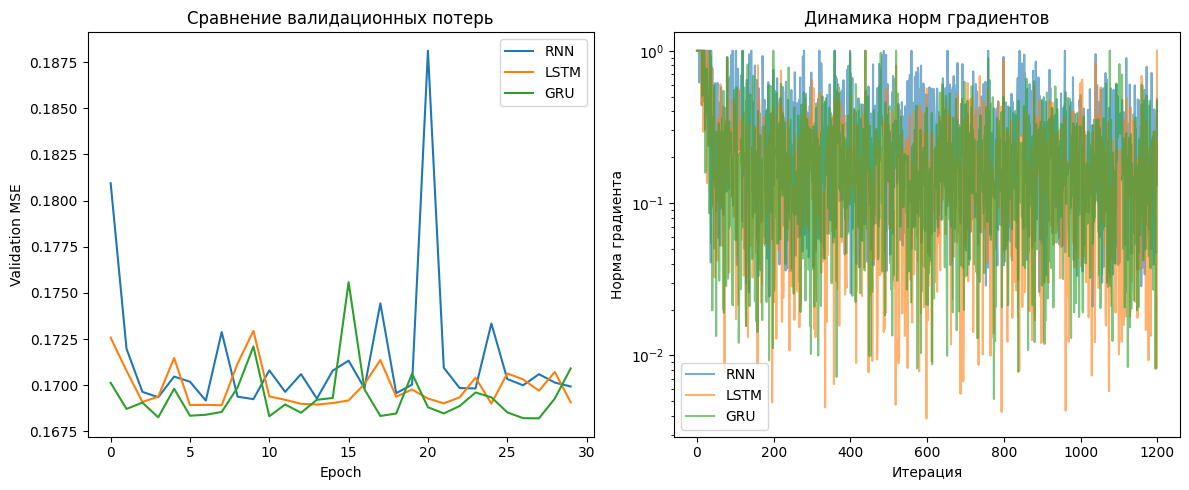

In [49]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

Теоретически надо было бы построить график такого плана:

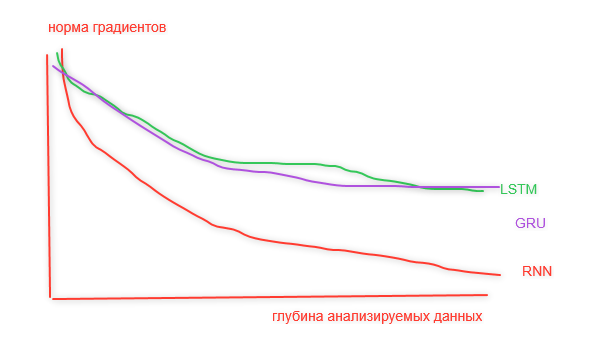

**Задание для интерпретации:**
1. Какая модель показала наименьшую ошибку на валидации? Почему, на ваш взгляд?
2. Посмотрите на график норм градиентов. Для какой модели градиенты быстрее всего уменьшаются? Связано ли это с проблемой затухания?
3. Попробуйте увеличить длину последовательности до 200 (сгенерируйте новые данные) и повторите обучение (измените `seq_len=200` в ячейке генерации). Что изменилось?

1. GRU показала наименьшую ошибку. У GRU есть gating-механизмы, которые лучше сохраняют информацию во времени, чем у обычной RNN, но при этом она проще и обучается стабильнее, чем LSTM.

2. Явного быстрого уменьшения ни у одной модели нет - градиенты у всех колеблются примерно в одном диапазоне.
Это не похоже на проблему затухания градиентов, потому что значения не уходят к нулю.


In [50]:
seq_len = 200
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 200, 2), Val shape: (1000, 200, 2)


In [51]:
batch_size = 128
train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [52]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 30

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs, use_scheduler=True)

Training Vanilla RNN...
Epoch 5: train_loss=0.1663, val_loss=0.1871
Epoch 10: train_loss=0.1627, val_loss=0.1905
Epoch 15: train_loss=0.1633, val_loss=0.1879
Epoch 20: train_loss=0.1622, val_loss=0.1901
Epoch 25: train_loss=0.1632, val_loss=0.1864
Epoch 30: train_loss=0.1670, val_loss=0.1868

Training LSTM...
Epoch 5: train_loss=0.1676, val_loss=0.1881
Epoch 10: train_loss=0.1600, val_loss=0.1856
Epoch 15: train_loss=0.1632, val_loss=0.1857
Epoch 20: train_loss=0.1636, val_loss=0.1874
Epoch 25: train_loss=0.1643, val_loss=0.1866
Epoch 30: train_loss=0.1618, val_loss=0.1868

Training GRU...
Epoch 5: train_loss=0.1633, val_loss=0.1855
Epoch 10: train_loss=0.1622, val_loss=0.1868
Epoch 15: train_loss=0.1621, val_loss=0.1851
Epoch 20: train_loss=0.1651, val_loss=0.1902
Epoch 25: train_loss=0.1649, val_loss=0.1851
Epoch 30: train_loss=0.1643, val_loss=0.1862


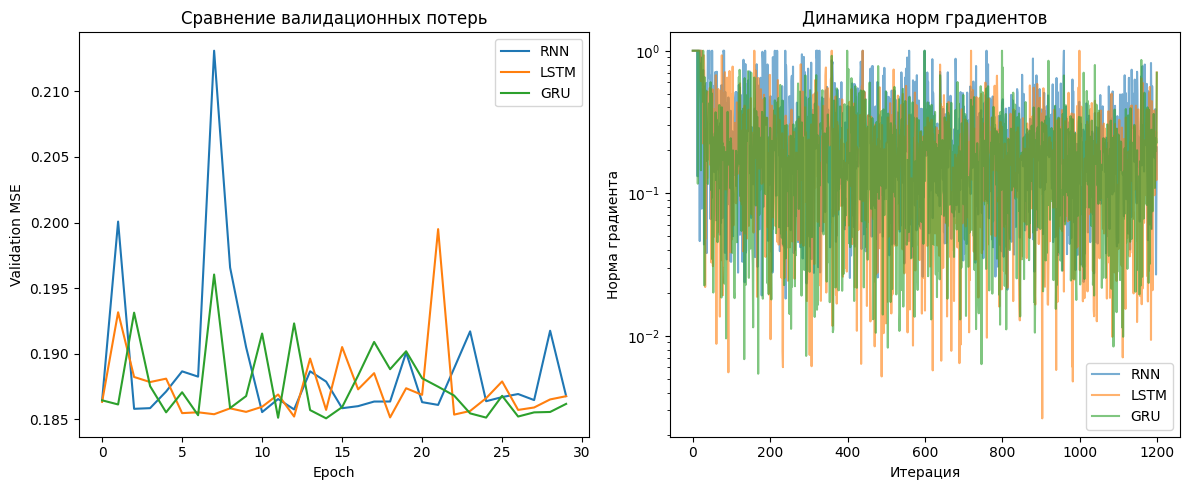

In [53]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

3. Ошибка у всех моделей выросла, RNN стала заметно нестабильнее

## **3. Эксперимент 2: Классификация тональности  комментариев на русском языке (RuSentiment)**

Используем датасет RuSentiment (отзывы о фильмах, размеченные по тональности: положительные, отрицательные, нейтральные).

**Задача:** обучить BiLSTM для классификации текста. Сравним однонаправленную LSTM и двунаправленную (BiLSTM), визуализируем скрытые состояния через t-SNE.

Labels meaning
0: NEUTRAL
1: POSITIVE
2: NEGATIVE

In [54]:
# Загружаем датасет с Hugging Face
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000')
print(dataset)

# Посмотрим на распределение классов
from collections import Counter
labels = [ex['sentiment'] for ex in dataset['train']]
print(Counter(labels))

# Разделим на train, val, test (80/10/10) с помощью sklearn
from sklearn.model_selection import train_test_split

# Преобразуем Dataset в список для индексации
train_data = list(dataset['train'])
train_labels = [ex['sentiment'] for ex in train_data]

# Разделение: сначала 80% train, 20% temp
train_data_split, temp_data = train_test_split(
    train_data, test_size=0.2, random_state=42, stratify=train_labels
)

# Из temp делаем val и test (50/50 от 20% = 10% + 10%)
temp_labels = [ex['sentiment'] for ex in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Train size: {len(train_data_split)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

Generating train split: 100%|██████████| 48212/48212 [00:00<00:00, 234446.02 examples/s]


DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 48212
    })
})
Counter({2: 16158, 0: 16054, 1: 16000})
Train size: 38569, Val size: 4821, Test size: 4822


In [55]:
# Используем простой токенизатор на основе пробелов
def simple_tokenize(text, max_len=50):
    tokens = text.lower().split()[:max_len]
    return tokens

# Построим словарь по train_data
vocab = {'<PAD>': 0, '<UNK>': 1}
for example in train_data:
    for token in simple_tokenize(example['text']):
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')

Vocabulary size: 233935


In [56]:
def text_to_ids(text, max_len=50):
    tokens = simple_tokenize(text, max_len)
    ids = [vocab.get(token, 1) for token in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids[:max_len]

class RuSentimentDataset(Dataset):
    def __init__(self, data_list, max_len=50):
        self.texts = [ex['text'] for ex in data_list]
        self.labels = [ex['sentiment'] for ex in data_list]
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = text_to_ids(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = RuSentimentDataset(train_data)
val_ds = RuSentimentDataset(val_data)
test_ds = RuSentimentDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [57]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1, bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out

# Параметры
embed_dim = 100
hidden_dim = 128
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True).to(device)

In [58]:
def train_sentiment(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for X_batch, y_batch in pbar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                _, predicted = torch.max(pred, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        val_accs.append(val_acc)
        print(f'Epoch {epoch+1}: avg_train_loss={train_losses[-1]:.4f}, val_acc={val_acc:.4f}')

    return train_losses, val_accs

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:09<00:00, 79.93it/s, loss=0.984]


Epoch 1: avg_train_loss=1.0539, val_acc=0.4787


Epoch 2/10: 100%|██████████| 754/754 [00:09<00:00, 82.63it/s, loss=1.1]  


Epoch 2: avg_train_loss=0.9509, val_acc=0.6163


...

Epoch 8: avg_train_loss=0.0543, val_acc=0.9919


Epoch 9/10: 100%|██████████| 754/754 [00:10<00:00, 73.52it/s, loss=0.348]  


Epoch 9: avg_train_loss=0.0447, val_acc=0.9907


Epoch 10/10: 100%|██████████| 754/754 [00:10<00:00, 73.63it/s, loss=0.0175] 


Epoch 10: avg_train_loss=0.0384, val_acc=0.9880


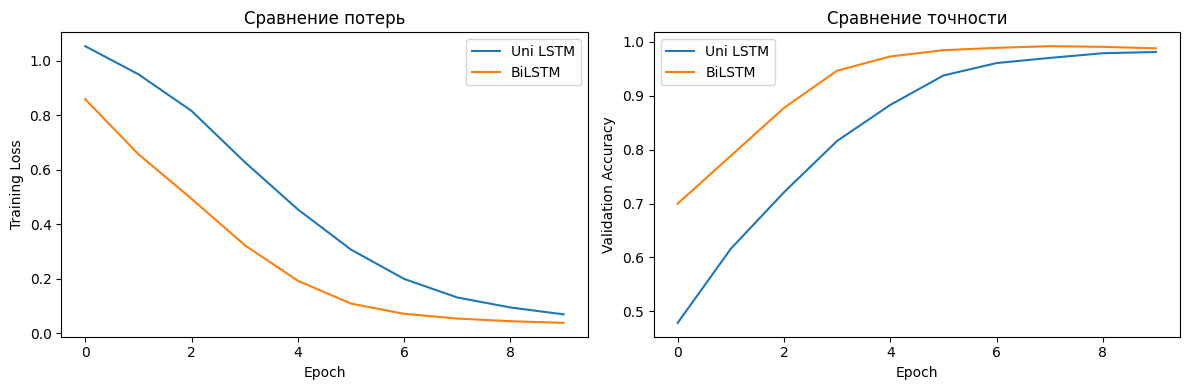

In [60]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

### **3.1. Визуализация скрытых состояний с помощью t-SNE (3 класса)**

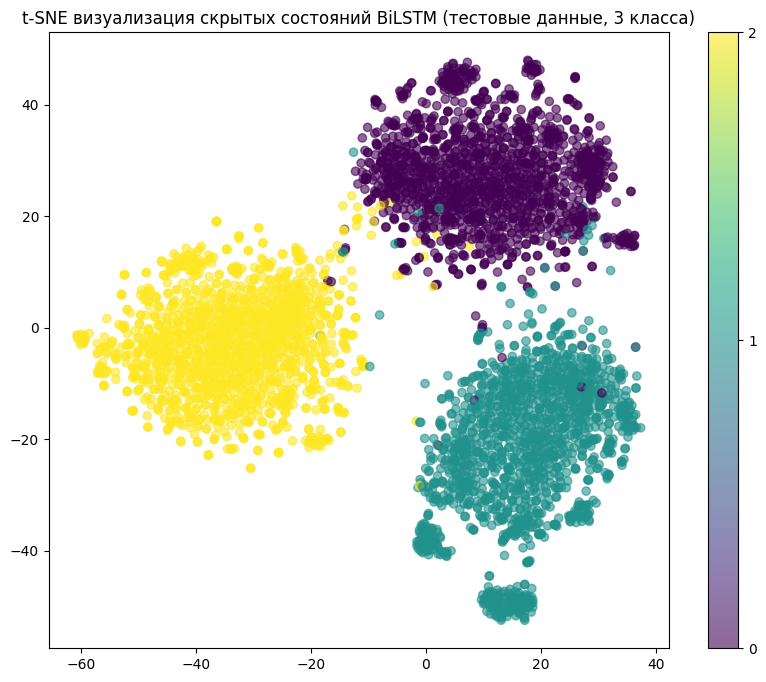

In [61]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

**Задание для интерпретации:**
1. Сравните точность однонаправленной и двунаправленной LSTM. Какая модель оказалась лучше и почему?
2. Посмотрите на t-SNE проекцию. Видны ли кластеры, соответствующие разным классам? Если нет, то что это может означать? Можно ли как-то эту информацию использовать?
3. (Дополнительно) Попробуйте изменить размер скрытого состояния (`hidden_dim`) и количество слоёв LSTM (`n_layers`). Как это влияет на точность и время обучения?

1. Лучше оказалась двунаправленная LSTM (val_acc = 0.9919)
2. Да, видны кластеры на t-SNE. Для чего нам эта информация : 
* Для визуальной проверки качества эмбеддингов.
* Для поиска выбросов и “пограничных” примеров.
* Для обучения более простого классификатора поверх скрытых состояний.
* Для анализа ошибок: если неверные примеры лежат между кластерами, значит модель путается на границе классов.

In [62]:
# Параметры
embed_dim = 100
hidden_dim = 256
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False, n_layers=2).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True,n_layers=2).to(device)

In [63]:
print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:14<00:00, 52.55it/s, loss=0.996]


Epoch 1: avg_train_loss=1.0542, val_acc=0.4866


Epoch 2/10: 100%|██████████| 754/754 [00:13<00:00, 54.22it/s, loss=1.29] 


Epoch 2: avg_train_loss=0.9743, val_acc=0.5184


...

Epoch 8: avg_train_loss=0.0563, val_acc=0.9865


Epoch 9/10: 100%|██████████| 754/754 [00:17<00:00, 44.12it/s, loss=0.036]  


Epoch 9: avg_train_loss=0.0446, val_acc=0.9890


Epoch 10/10: 100%|██████████| 754/754 [00:17<00:00, 44.13it/s, loss=0.0261] 


Epoch 10: avg_train_loss=0.0384, val_acc=0.9886


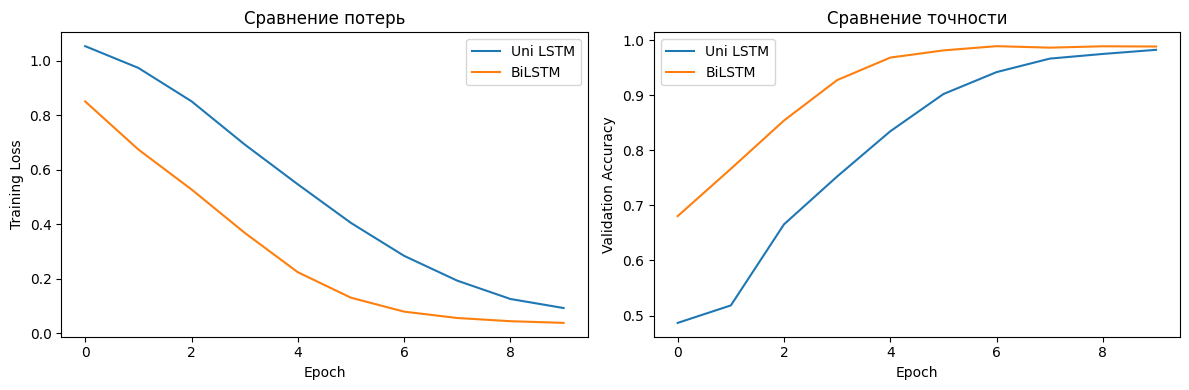

In [64]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

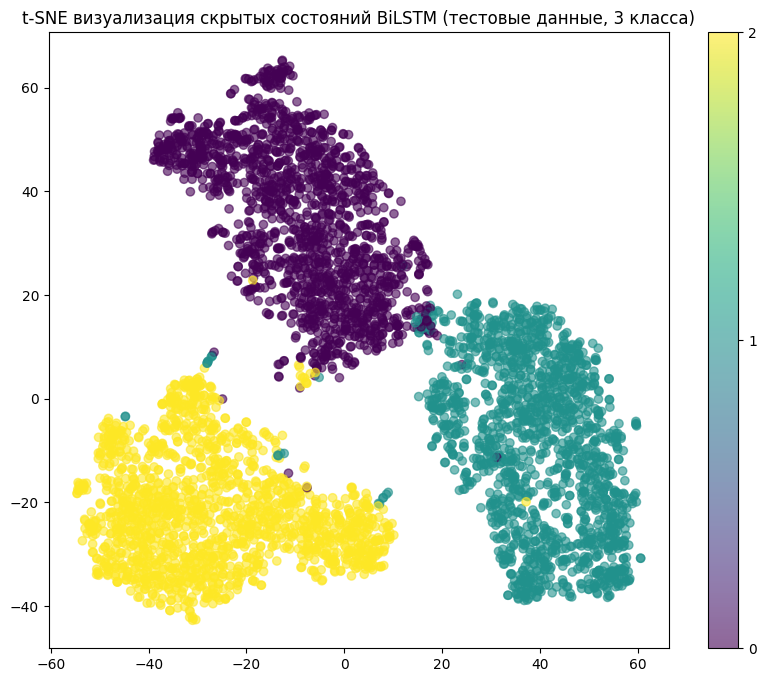

In [65]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

3. Поставил hidden_dim = 256, n_layers=2 - время обучение увеличилось, метрики чуть-чуть увеличелись (не значительно)

## **Заключение**

В этом практическом занятии мы:
- Убедились, что LSTM и GRU значительно лучше справляются с долгосрочными зависимостями, чем vanilla RNN.
- Визуализировали градиенты и увидели, что в RNN они быстро затухают.
- Применили BiLSTM для классификации русскоязычных текстов и сравнили с однонаправленной версией.
- Использовали t-SNE для визуализации скрытых представлений.

Попробуйте поэкспериментировать с гиперпараметрами и, возможно, применить предобученные эмбеддинги (FastText) для улучшения качества.

* Что нового узнали? Навыки/умения/знания.
* Обратная связь: что изменить по наполнению блокнотов материалам или способу подачи материала?